# 01 - full 2y run, $1000 account

Run the current `volume_weighted_breakout` strategy over the standard visible research window `2024-01-01` -> `2026-01-01`. The harness starts from its canonical account size internally; equity and benchmark are rebased to `$1000` for display. This keeps returns, Sharpe, drawdown, funding effects, and trades identical while making the chart readable as a small account.

In [1]:
import json
import sys; sys.path.insert(0, ".")   # cwd = notebooks/volume_weighted_breakout
from _lab import *

symbols = list(strategy.DEFAULT_SYMBOLS)
start, end = "2024-01-01", "2026-01-01"
initial_cash = 1000.0

print("strategy:", strategy.__name__)
print("TF:", strategy.DEFAULT_TF)
print("symbols:", symbols)
for sym in symbols:
    print(f"{sym} coverage:", coverage(sym))

strategy: strategy_volume_weighted_breakout
TF: 4h
symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']
BTCUSDT coverage: ('2024-01', '2026-05', 29)
ETHUSDT coverage: ('2024-01', '2026-05', 29)
SOLUSDT coverage: ('2024-01', '2026-05', 29)


In [2]:
result = run_pair(symbols, start, end, return_curves=True)
metrics_frame(result)

,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,1.027273,0.731725,0.106957,0.219670,160,14.285714,1.380866
oos,-1.300275,-0.539577,0.141391,-0.092367,46,12.682482,0.550518


In [3]:
curves = result["curves"]
equity = rebase(curves["equity"], initial_cash)
benchmark = rebase(curves["benchmark"], initial_cash)
raw_equity = rebase(curves["raw_equity"], initial_cash)
dd = drawdown(equity)
cutoff = curves["split_cutoff"]

summary = pd.Series({
    "start_equity": equity.iloc[0],
    "end_equity": equity.iloc[-1],
    "total_return": equity.iloc[-1] / equity.iloc[0] - 1.0,
    "max_drawdown": dd.min(),
    "benchmark_end": benchmark.iloc[-1],
    "bars": len(equity),
})
summary

start_equity     1000.000000
end_equity       1105.403446
total_return        0.105403
max_drawdown       -0.173322
benchmark_end    1526.372229
bars             4386.000000
dtype: float64

[saved] notebooks\volume_weighted_breakout\_out\01_full_period_1000_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/01_full_period_1000_equity_drawdown.png')

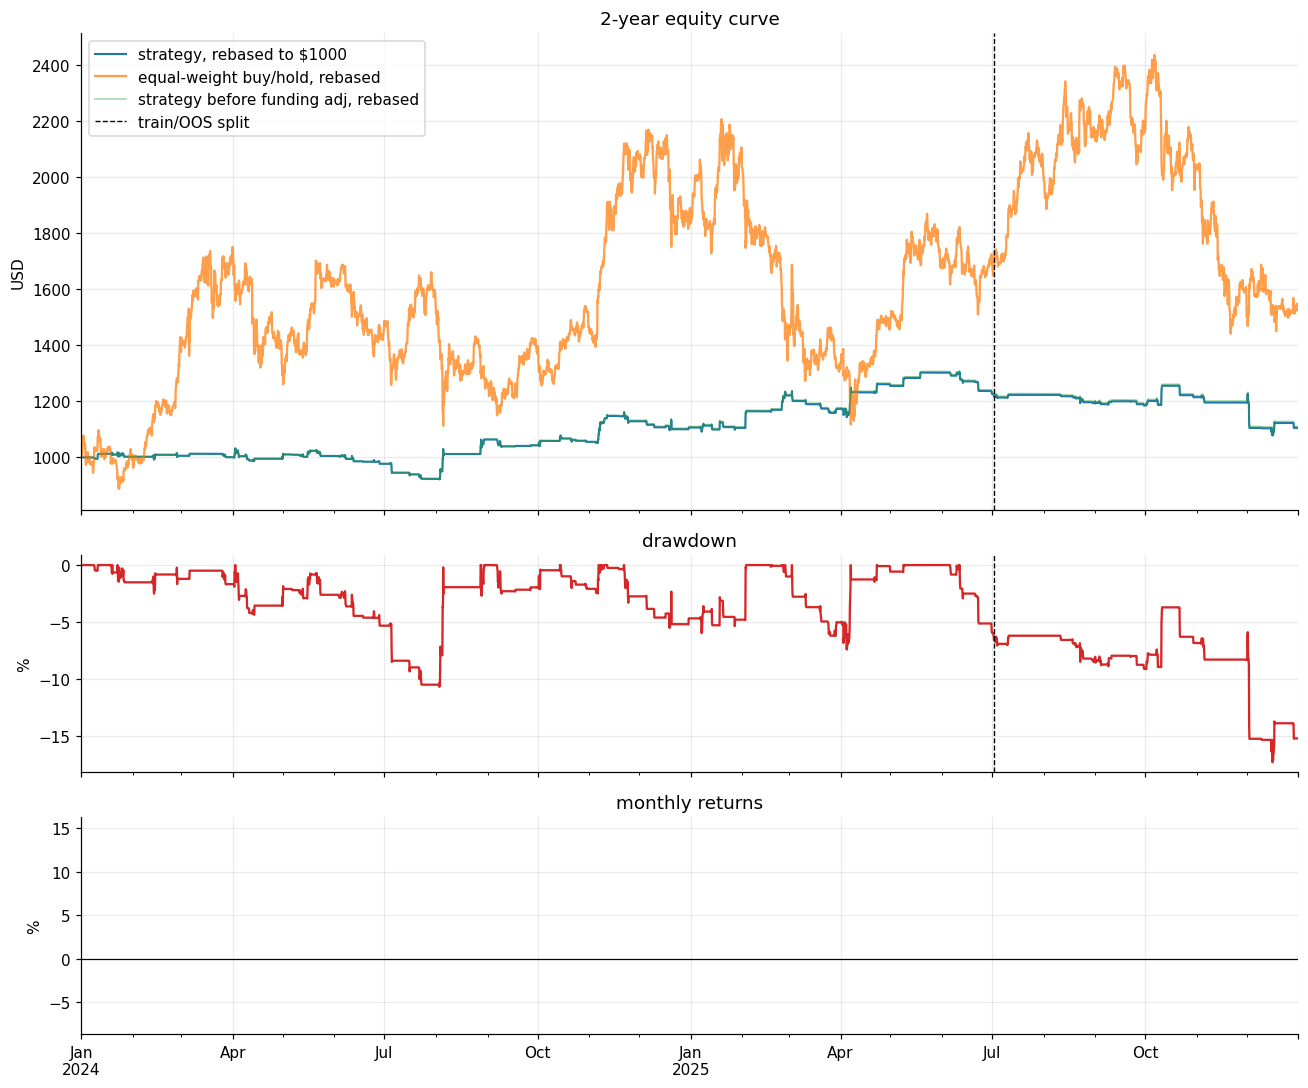

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0, 1.0]})

equity.plot(ax=ax[0], label="strategy, rebased to $1000", lw=1.4)
benchmark.plot(ax=ax[0], label="equal-weight buy/hold, rebased", alpha=0.75)
raw_equity.plot(ax=ax[0], label="strategy before funding adj, rebased", alpha=0.45, lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--", label="train/OOS split")
ax[0].set_title("2-year equity curve")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")

(dd * 100).plot(ax=ax[1], color="C3")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("drawdown")
ax[1].set_ylabel("%")

mret = monthly_returns(equity) * 100
colors = np.where(mret >= 0, "C2", "C3")
ax[2].bar(mret.index, mret.values, width=20, color=colors, alpha=0.8)
ax[2].axhline(0, color="k", lw=0.8)
ax[2].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[2].set_title("monthly returns")
ax[2].set_ylabel("%")

show("01_full_period_1000_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\01_full_period_1000_positions.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/01_full_period_1000_positions.png')

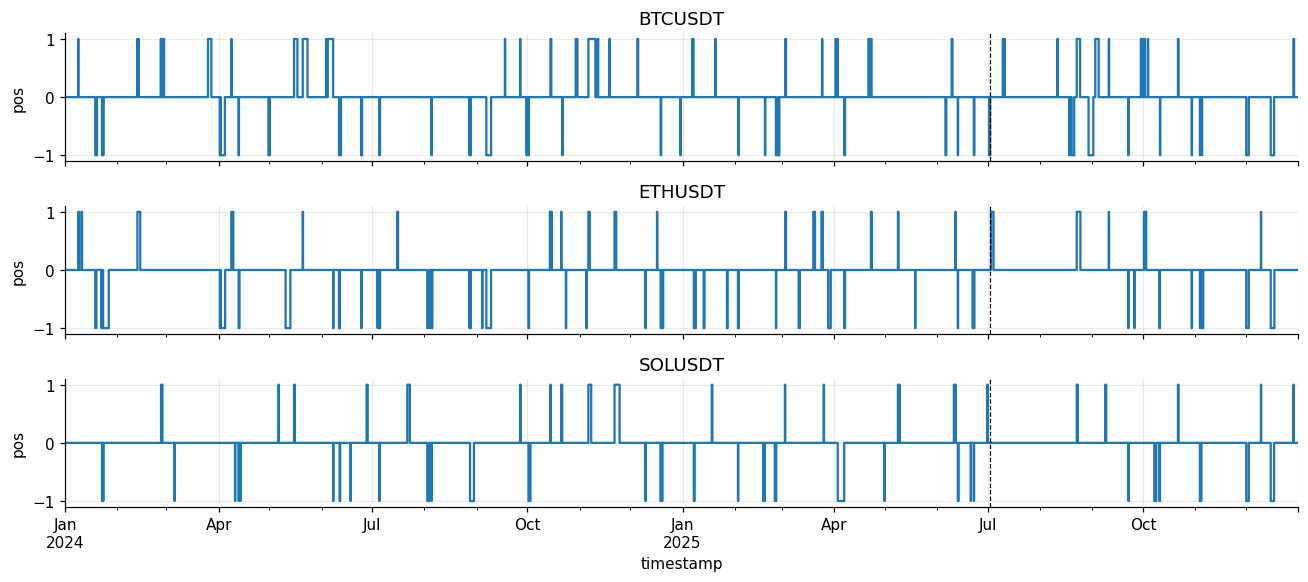

In [5]:
signals = generate_pair_signals(symbols, start, end)
pos = positions_wide(signals).reindex(equity.index).ffill().fillna(0.0)

fig, ax = plt.subplots(len(symbols), 1, figsize=(12, 1.8 * len(symbols)), sharex=True)
if len(symbols) == 1:
    ax = [ax]
for axis, sym in zip(ax, symbols):
    pos[sym].plot(ax=axis, drawstyle="steps-post")
    axis.axvline(cutoff, color="k", lw=0.8, ls="--")
    axis.set_title(sym)
    axis.set_ylim(-1.1, 1.1)
    axis.set_ylabel("pos")
show("01_full_period_1000_positions")

In [6]:
trades = curves["trades"].copy()
print("trades:", len(trades))
trades.head(10)

trades: 206


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
0,2024-01-08 16:00:00+00:00,2024-01-08 20:00:00+00:00,BTCUSDT,Long,0.070913,47010.600590,46968.102720,-6.679031,-0.002004,4.0,train,3333.666667,1.041296e+10,0.000032
1,2024-01-18 20:00:00+00:00,2024-01-19 20:00:00+00:00,BTCUSDT,Short,0.084297,41314.561392,41667.403249,-33.590719,-0.009645,24.0,train,3482.681919,6.392147e+09,0.000054
2,2024-01-22 20:00:00+00:00,2024-01-23 00:00:00+00:00,BTCUSDT,Short,0.085769,39555.344070,40001.299730,-42.001890,-0.012380,4.0,train,3392.605948,9.404445e+09,0.000036
3,2024-01-23 12:00:00+00:00,2024-01-23 16:00:00+00:00,BTCUSDT,Short,0.085361,39190.180590,39136.913300,0.869611,0.000260,4.0,train,3345.332311,7.457425e+09,0.000045
4,2024-02-12 16:00:00+00:00,2024-02-13 16:00:00+00:00,BTCUSDT,Long,0.068438,49555.267056,49052.324600,-38.131869,-0.011244,24.0,train,3391.446877,9.503901e+09,0.000036
5,2024-02-26 16:00:00+00:00,2024-02-26 20:00:00+00:00,BTCUSDT,Long,0.061695,54543.153770,54509.548500,-5.773682,-0.001716,4.0,train,3365.040585,9.246236e+09,0.000036
6,2024-02-27 04:00:00+00:00,2024-02-27 08:00:00+00:00,BTCUSDT,Long,0.060008,56105.610000,56584.440990,25.014630,0.007430,4.0,train,3366.813359,1.252716e+10,0.000027
7,2024-02-28 12:00:00+00:00,2024-02-28 16:00:00+00:00,BTCUSDT,Long,0.054987,61012.700660,61021.797210,-3.190491,-0.000951,4.0,train,3354.918484,2.740159e+10,0.000012
8,2024-03-25 16:00:00+00:00,2024-03-27 16:00:00+00:00,BTCUSDT,Long,0.049569,70972.117528,68729.434509,-114.975638,-0.032682,48.0,train,3517.998740,1.154214e+10,0.000030
9,2024-04-01 16:00:00+00:00,2024-04-01 20:00:00+00:00,BTCUSDT,Short,0.047924,69677.331570,69713.770680,-5.420445,-0.001623,4.0,train,3339.240276,8.718340e+09,0.000038


In [7]:
if len(trades):
    by_symbol = trades.groupby("symbol").agg(
        n=("symbol", "size"),
        pnl_quote=("pnl_quote", "sum"),
        avg_return=("return_pct", "mean"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_duration_h=("duration_hours", "mean"),
    ).sort_values("pnl_quote", ascending=False)
    display(by_symbol)
    display(trades.tail(10))
else:
    print("No trades in this period.")

,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
SOLUSDT,57,1572.035603,0.006864,0.526316,13.964912
ETHUSDT,71,1082.242751,0.004547,0.450704,15.943662
BTCUSDT,78,-1545.707865,-0.005081,0.333333,17.384615


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
196,2025-09-22 08:00:00+00:00,2025-09-22 12:00:00+00:00,SOLUSDT,Short,18.134390,221.407857,220.662064,9.115333,0.002270,4.0,oos,4015.096403,4.146339e+09,0.000097
197,2025-10-07 16:00:00+00:00,2025-10-08 20:00:00+00:00,SOLUSDT,Short,18.526324,221.516074,228.813916,-139.790801,-0.034063,28.0,oos,4103.878535,3.330142e+09,0.000123
198,2025-10-10 16:00:00+00:00,2025-10-11 00:00:00+00:00,SOLUSDT,Short,22.029495,203.134153,184.108409,414.435611,0.092612,8.0,oos,4474.942837,7.209039e+09,0.000062
199,2025-10-21 16:00:00+00:00,2025-10-22 00:00:00+00:00,SOLUSDT,Long,22.084679,193.765067,185.081490,-196.375692,-0.045890,8.0,oos,4279.239357,3.494012e+09,0.000122
200,2025-11-03 16:00:00+00:00,2025-11-03 20:00:00+00:00,SOLUSDT,Short,24.412427,166.593339,165.946593,11.323681,0.002784,4.0,oos,4066.947782,3.734925e+09,0.000109
201,2025-11-04 08:00:00+00:00,2025-11-04 12:00:00+00:00,SOLUSDT,Short,25.267986,161.623836,161.406139,1.011490,0.000248,4.0,oos,4083.908845,4.591306e+09,0.000089
202,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,SOLUSDT,Short,33.197590,127.160035,139.076783,-400.468421,-0.094866,36.0,oos,4221.406686,2.001363e+09,0.000211
203,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,Long,26.862077,137.823781,138.056193,2.167179,0.000585,4.0,oos,3702.233078,2.005351e+09,0.000185
204,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,SOLUSDT,Short,32.127318,125.085829,122.936324,64.675267,0.016094,48.0,oos,4018.672144,1.692159e+09,0.000237
205,2025-12-29 04:00:00+00:00,2025-12-29 08:00:00+00:00,SOLUSDT,Long,29.420374,127.842783,125.007498,-87.506568,-0.023266,4.0,oos,3761.182508,1.469704e+09,0.000256


In [8]:
# Full metric payload, excluding the large curve/trade objects already shown above.
print(json.dumps(clean_metrics(result), indent=2, default=str))

{
  "strategy": "volume_weighted_breakout",
  "params": {
    "breakout_lookback": 20,
    "volume_ma": 20,
    "volume_mult": 3.0,
    "atr_period": 14,
    "take_atr": 2.5,
    "max_hold_bars": 30
  },
  "symbols": [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT"
  ],
  "tf": "4h",
  "period": [
    "2024-01-01",
    "2026-01-01"
  ],
  "main": {
    "train": {
      "sharpe": 1.0272732625176302,
      "bench_sharpe": 0.8655719493577722,
      "alpha_sharpe": 0.16170131315985803,
      "information_ratio": -0.6032794843913715,
      "sortino": 0.7317251915633005,
      "calmar": 1.322684161411834,
      "cagr": 0.14146974558806336,
      "max_dd": 0.1069565582739408,
      "total_return": 0.2196704312939204,
      "target_turnover": 0.581056466302368,
      "hit_rate": 0.37985865724381623,
      "n_trades": 160,
      "n_periods": 3290,
      "psr": 0.9058330767589143,
      "sharpe_ci_lo": -0.6524472707935306,
      "sharpe_ci_hi": 2.4545699377201506,
      "max_participation_pct": 0.0